# Exercise

In [1]:
# You can add any other libraries you would like
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as Fc
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Step 1: Dataset

In this exercise, we want to train an MLP on CIFAR10 dataset and plan to reach a reasonable accuracy

Step 1 is to load the dataset

In [2]:
# TODO: Define transformations to normalize the dataset
mean = [0.4914, 0.4822, 0.4465]
std  = [0.2023, 0.1994, 0.2010]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# TODO: Download the training and test datasets
train_dataset = torchvision.datasets.CIFAR10(root='./data/exercise', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data/exercise', train=False, download=True, transform=transform)

# TODO: Wrap them in DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=200)

When working with a new dataset, it is always a good idea to visualize the data and print some information about it.

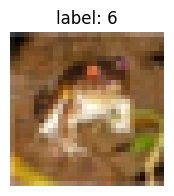

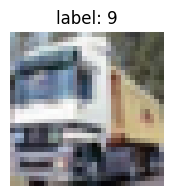

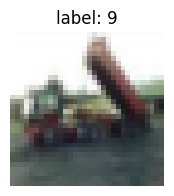

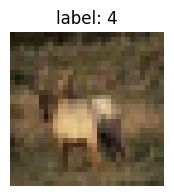

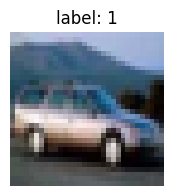

In [3]:
classes = train_dataset.classes

def imshow(img, label, pred=None):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    img = img * std + mean
    npimg = img.numpy().transpose((1, 2, 0))
    plt.figure(figsize=(2, 2))
    plt.imshow(np.clip(npimg, 0, 1))
    if pred:
        plt.title(f"label: {label}, pred: {pred}")
    else:
        plt.title(f"label: {label}")
    plt.axis("off")
    plt.show()
    

# TODO: Show images
for i in range(5):
    image, label = train_dataset[i]
    imshow(image, label)

## Model

In [4]:
# TODO: define model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.layer(x)

## Train

In [5]:
model = MLP().to(device)

# TODO: choose a loss function and an optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)

In [6]:
def train_model(model, epochs):
    losses = []
    for epoch in range(epochs):
        # TODO: Complete the training loop
        running_loss = 0.0
        for image, label in train_loader:
            pred = model(image)
            loss = criterion(pred, label)

            optimizer.zero_grad()
            loss.backward()     
            optimizer.step()

            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        losses.append(avg_loss)
        print(f'Epoch: {epoch + 1}, Loss: {avg_loss:.4f}')
        
    return losses

In [7]:
train_losses = train_model(model, 30)

Epoch: 1, Loss: 1.7226
Epoch: 2, Loss: 1.5431
Epoch: 3, Loss: 1.4579
Epoch: 4, Loss: 1.3856
Epoch: 5, Loss: 1.3283
Epoch: 6, Loss: 1.2738
Epoch: 7, Loss: 1.2216
Epoch: 8, Loss: 1.1748
Epoch: 9, Loss: 1.1275
Epoch: 10, Loss: 1.0909
Epoch: 11, Loss: 1.0566
Epoch: 12, Loss: 1.0169
Epoch: 13, Loss: 0.9862
Epoch: 14, Loss: 0.9523
Epoch: 15, Loss: 0.9108
Epoch: 16, Loss: 0.8996
Epoch: 17, Loss: 0.8631
Epoch: 18, Loss: 0.8387
Epoch: 19, Loss: 0.8118
Epoch: 20, Loss: 0.7904
Epoch: 21, Loss: 0.7733
Epoch: 22, Loss: 0.7591
Epoch: 23, Loss: 0.7364
Epoch: 24, Loss: 0.7110
Epoch: 25, Loss: 0.6916
Epoch: 26, Loss: 0.6934
Epoch: 27, Loss: 0.6654
Epoch: 28, Loss: 0.6467
Epoch: 29, Loss: 0.6423
Epoch: 30, Loss: 0.6149


## Evaluation

In [8]:
def test_model(model):
    # TODO: Prepare for the loop
    acc = 0
    with torch.no_grad():
        # TODO: Complete the test loop
        model.eval()
        for image, label in test_loader:
            pred = model(image)
            acc += (pred.argmax(dim=1) == label).float().mean().item()
        
        accuracy = acc / len(test_loader)

    print(f"Accuracy on test set: {accuracy:.4f}%")

In [9]:
test_model(model)

Accuracy on test set: 0.5262%


### Visualization

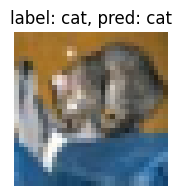

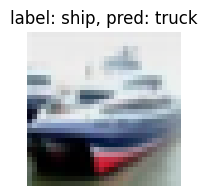

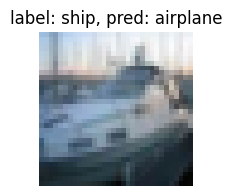

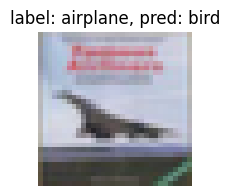

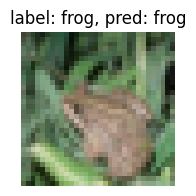

In [14]:
images, labels = next(iter(test_loader))
preds = model(images)
predicted = torch.argmax(preds, dim=1)

for i in range(5):
    imshow(images[i], classes[labels[i]], classes[predicted[i]])    